**Cellule 1 : Chargement du graphe et des bibliothèques**

In [1]:
#importation les bibliothéques nécessaires
import pandas as pd
import networkx as nx
from networkx.algorithms import community as nx_comm
import matplotlib.pyplot as plt
import random

In [2]:
# 1. Chargement de la matrice d'adjacence des employés
df_adj = pd.read_csv("../resultats/matrice_adjacence_employees.csv", index_col=0)
G_emp = nx.from_pandas_adjacency(df_adj)

In [3]:
# 2. Chargement des noms pour l'interprétation
df_data = pd.read_csv("../data/linkedin_cleaned_data.csv")
nom_attr = dict(zip(df_data['id'].astype(str), df_data['name']))
nx.set_node_attributes(G_emp, nom_attr, 'name')

print(f"✅ Graphe chargé : {G_emp.number_of_nodes()} nœuds et {G_emp.number_of_edges()} liens.")

✅ Graphe chargé : 1000 nœuds et 1133 liens.


**Cellule 2 : Application des Algorithmes**

In [4]:
# --- 1. LOUVAIN (Basé sur la modularité) ---
comm_louvain = list(nx_comm.louvain_communities(G_emp, seed=42))

# --- 2. LABEL PROPAGATION (Basé sur la diffusion) ---
comm_label_prop = list(nx_comm.label_propagation_communities(G_emp))

# --- 3. GIRVAN-NEWMAN (Basé sur les ponts/Betweenness) ---
# On ne prend que la première division (top-level) pour gagner du temps
comp_gn = nx_comm.girvan_newman(G_emp)
comm_gn = list(next(comp_gn))

print("✅ Algorithmes exécutés avec succès.")

✅ Algorithmes exécutés avec succès.


**Cellule 3 : Évaluation et Comparaison**

In [5]:
#Création une fonction pour l'évaluation
def evaluer_partition(graphe, partition, nom_algo):
    mod = nx_comm.modularity(graphe, partition)
    nb_comm = len(partition)
    tailles = [len(c) for c in partition]
    return {
        'Algo': nom_algo,
        'Modularité': round(mod, 4),
        'Nb Communautés': nb_comm,
        'Taille Moyenne': round(sum(tailles)/nb_comm, 1),
        'Max Taille': max(tailles)
    }

In [6]:
# Calcul des métriques
resultats = [
    evaluer_partition(G_emp, comm_louvain, "Louvain"),
    evaluer_partition(G_emp, comm_label_prop, "Label Propagation"),
    evaluer_partition(G_emp, comm_gn, "Girvan-Newman")
]

df_comparaison = pd.DataFrame(resultats)
print(df_comparaison.to_string(index=False))

             Algo  Modularité  Nb Communautés  Taille Moyenne  Max Taille
          Louvain      0.9377             561             1.8          31
Label Propagation      0.9065             578             1.7          29
    Girvan-Newman      0.8955             552             1.8          86


In [7]:
# Sauvegarde de la comparaison
df_comparaison.to_csv("../resultats/comparaison_communautes.csv", index=False)

**Cellule 4 : Visualisation de la meilleure partition**

In [8]:
# Choix de l'algorithme 
best_partition = comm_louvain 
dict_partition = {node: i for i, comm in enumerate(best_partition) for node in comm}

In [9]:
# Échantillon pour la visualisation
taille_visu = 100
nodes_visu = random.sample(list(G_emp.nodes()), taille_visu)
sub_visu = G_emp.subgraph(nodes_visu).copy()

In [10]:
# Suppression des isolés pour le visuel
sub_visu.remove_nodes_from([n for n, d in sub_visu.degree() if d == 0])

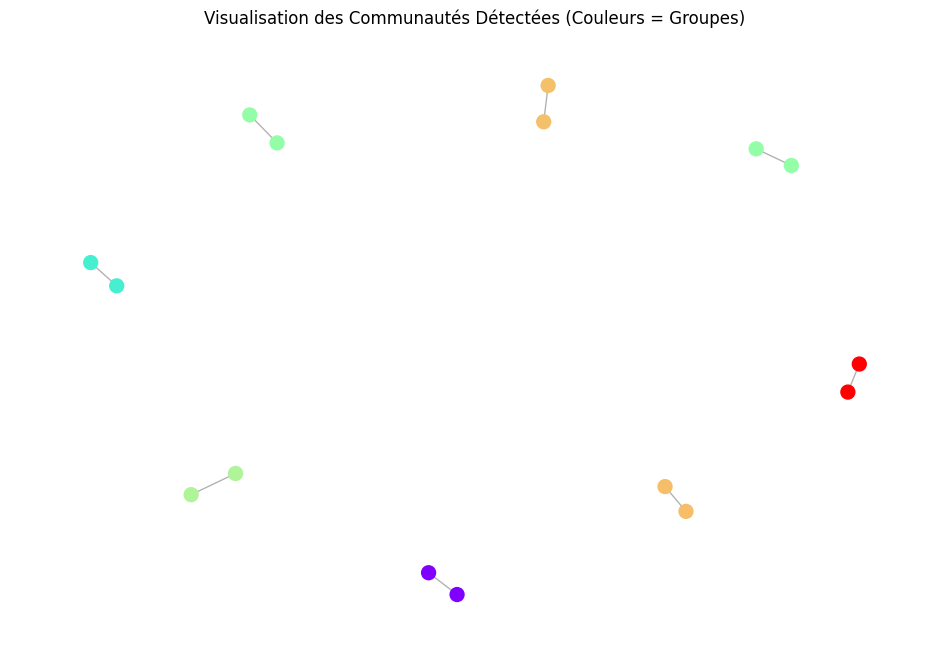

In [11]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(sub_visu, k=0.3, seed=42)

# On colore par ID de communauté
colors = [dict_partition[n] for n in sub_visu.nodes()]

nx.draw_networkx_nodes(sub_visu, pos, node_size=100, node_color=colors, cmap=plt.cm.rainbow)
nx.draw_networkx_edges(sub_visu, pos, alpha=0.3)

plt.title("Visualisation des Communautés Détectées (Couleurs = Groupes)")
plt.axis('off')
plt.savefig("../resultats/visualisation_communautes.png", dpi=300)
plt.show()